<a href="https://colab.research.google.com/github/BhagwatiOracle/KrishiVani/blob/main/Fine_tuning_VIT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [ ]:
from datasets import load_dataset

dataset1 = load_dataset("sharmin3/Rice-Leaf-Disease")

README.md:   0%|          | 0.00/319 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Rice Leaf Disease-20241115T062818Z-001.z(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7421 [00:00<?, ? examples/s]

In [ ]:
dataset1 = dataset1['train'].shuffle().select(range(2000))

In [ ]:
from datasets import load_dataset
dataset2 = load_dataset("Prachi1234/corn-leaf-disease")

archive.zip:   0%|          | 0.00/169M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4188 [00:00<?, ? examples/s]

In [ ]:
dataset2 = dataset2['train'].shuffle().select(range(2000))

In [ ]:


from roboflow import Roboflow
rf = Roboflow(api_key="LLDhy4hz6Agj4IdZqnPu")
project = rf.workspace("wheat-disease-ntkxi").project("wheat-disease-classification-82mlk")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Wheat-Disease-Classification-1 in folder:: 100%|██████████| 1495/1495 [00:01<00:00, 1147.65it/s]


In [ ]:
dataset3 = load_dataset("/content/Wheat-Disease-Classification-1",split='train')

Resolving data files:   0%|          | 0/1187 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/139 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/149 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

# **Merging Dataset**

In [ ]:
from datasets import ClassLabel, concatenate_datasets

# Extract string names from each dataset's label feature
labels_ds1 = dataset1.features["label"].names
labels_ds2 = dataset2.features["label"].names
labels_ds3 = dataset3.features["label"].names

# Merge into a single unique sorted list
unified_names = sorted(list(set(labels_ds1 + labels_ds2 + labels_ds3)))

# Create the new master ClassLabel feature object
unified_class_label = ClassLabel(names=unified_names)

In [ ]:
def remap_ds1(example):
    # Convert old ID to string name, then convert name to new unified ID
    string_name = dataset1.features["label"].int2str(example["label"])
    example["label"] = unified_class_label.str2int(string_name)
    return example

def remap_ds2(example):
    # Convert old ID to string name, then convert name to new unified ID
    string_name = dataset2.features["label"].int2str(example["label"])
    example["label"] = unified_class_label.str2int(string_name)
    return example

def remap_ds3(example):
    # Convert old ID to string name, then convert name to new unified ID
    string_name = dataset3.features["label"].int2str(example["label"])
    example["label"] = unified_class_label.str2int(string_name)
    return example

In [ ]:
from datasets import Features, Image

# Define the new features for ds1
new_features_ds1 = Features({
    "image": dataset1.features["image"],
    "label": unified_class_label
})

# Define the new features for ds2
new_features_ds2 = Features({
    "image": dataset2.features["image"],
    "label": unified_class_label
})

# Define the new features for ds3
new_features_ds3 = Features({
    "image": dataset3.features["image"],
    "label": unified_class_label
})

ds1 = dataset1.map(remap_ds1, features=new_features_ds1)
ds2 = dataset2.map(remap_ds2, features=new_features_ds2)
ds3 = dataset3.map(remap_ds3, features=new_features_ds3)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1187 [00:00<?, ? examples/s]

In [ ]:
ds1 = ds1.cast_column("label",unified_class_label)
ds2 = ds2.cast_column("label",unified_class_label)
ds3 = ds3.cast_column("label",unified_class_label)

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1187 [00:00<?, ? examples/s]

In [ ]:
from datasets import concatenate_datasets

final_dataset = concatenate_datasets([ds1, ds2, ds3])

In [ ]:
final_dataset.features['label']

ClassLabel(names=['Bacterialblight', 'BlackPoint', 'Blast', 'Blight', 'Brownspot', 'Common_Rust', 'FusariumFootRot', 'Gray_Leaf_Spot', 'Healthy', 'HealthyLeaf', 'LeafBlight', 'Tungro', 'WheatBlast'])

In [ ]:
final_dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 5187
})

# **Train-Test Split**

In [ ]:
# Use the train_test_split method of the dataset object
dataset = final_dataset.train_test_split(test_size=0.2, shuffle=True)


In [ ]:
dataset['train'].features['label']

ClassLabel(names=['Bacterialblight', 'BlackPoint', 'Blast', 'Blight', 'Brownspot', 'Common_Rust', 'FusariumFootRot', 'Gray_Leaf_Spot', 'Healthy', 'HealthyLeaf', 'LeafBlight', 'Tungro', 'WheatBlast'])

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4149
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1038
    })
})

# **Data Preprocessing**

1. Label Mapping

In [ ]:
id2label = {id:label for id, label in enumerate(dataset['train'].features['label'].names)}
label2id = {label:id for id,label in id2label.items()}

In [ ]:
id2label


{0: 'Bacterialblight',
 1: 'BlackPoint',
 2: 'Blast',
 3: 'Blight',
 4: 'Brownspot',
 5: 'Common_Rust',
 6: 'FusariumFootRot',
 7: 'Gray_Leaf_Spot',
 8: 'Healthy',
 9: 'HealthyLeaf',
 10: 'LeafBlight',
 11: 'Tungro',
 12: 'WheatBlast'}

2. Image Processing

In [ ]:
from transformers import ViTImageProcessor

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

3. Image Augmentation

In [ ]:
from torchvision.transforms import CenterCrop, Compose, Normalize, RandomHorizontalFlip, RandomResizedCrop, ToTensor, Resize

image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size['height']

normalize = Normalize(mean=image_mean, std=image_std)

train_transforms = Compose([
    RandomResizedCrop(size),
    RandomHorizontalFlip(),
    ToTensor(),
    normalize,
])

val_transform = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,

])

test_transforms =  Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

In [ ]:
def apply_train_transforms(examples):
  examples['pixel_values'] = [train_transforms(image.convert("RGB")) for image in examples['image']]
  return examples

def apply_val_transforms(examples):
  examples['pixel_values'] = [val_transform(image.convert("RGB")) for image in examples['image']]
  return examples

def apply_test_transforms(examples):
  examples['pixel_values'] = [test_transforms(image.convert("RGB")) for image in examples['image']]
  return examples

In [ ]:
train_ds = dataset['train']
test_ds = dataset['test']

In [ ]:
train_ds.set_transform(apply_train_transforms)
test_ds.set_transform(apply_test_transforms)

4. Data Loading

In [ ]:
import torch
from torch.utils.data import DataLoader

def collate_fn(examples):
  pixel_values = torch.stack([example['pixel_values'] for example in examples])
  labels = torch.tensor([example['label'] for example in examples])
  return {'pixel_values': pixel_values, 'labels': labels}

train_dl = DataLoader(train_ds, collate_fn=collate_fn, batch_size=8, shuffle=True)

In [ ]:
batch = next(iter(train_dl))
for k,v in batch.items():
  if isinstance(v, torch.Tensor):
    print(k, v.shape)

pixel_values torch.Size([8, 3, 224, 224])
labels torch.Size([8])


# **Fine-Tuning**

In [ ]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([13, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([13])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np

train_args = TrainingArguments(
    output_dir = "Rice-Wheat-Corn-DiseaseCLS",
    save_total_limit=2,
    report_to="wandb",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.05,
    load_best_model_at_end=True,
    logging_dir='logs',
    remove_unused_columns=False,
    fp16=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model,
    train_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collate_fn,
    processing_class=processor,
)
trainer.train()

invalid escape sequence '\/'
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bhagwati101x (bhagwati101x-its-engineering-college) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=780, training_loss=0.2752500974214994, metrics={'train_runtime': 1192.8729, 'train_samples_per_second': 10.434, 'train_steps_per_second': 0.654, 'total_flos': 9.646378885446267e+17, 'train_loss': 0.2752500974214994, 'epoch': 3.0})

In [ ]:
trainer.model.save_pretrained("Rice-Wheat-Corn-DiseaseCLS")
processor.save_pretrained("Rice-Wheat-Corn-DiseaseCLS")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['Rice-Wheat-Corn-DiseaseCLS/preprocessor_config.json']

# **Testing**

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch

In [ ]:
MODEL_NAME='/content/Rice-Wheat-Corn-DiseaseCLS'
extractor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(MODEL_NAME)

model.eval()

def predict_disease(image_path: str, top_k: int=3):
  image = Image.open(image_path).convert("RGB")
  inputs = extractor(images=image, return_tensors='pt')

  with torch.no_grad():
    logits = model(**inputs).logits

  probs = torch.softmax(logits, dim=-1)[0]
  top_indices = probs.topk(top_k).indices.tolist()

  results = []
  for idx in top_indices:
    label = model.config.id2label[idx]
    confidence = probs[idx].item() * 100
    results.append({
        "disease": label,
        'confidence': round(confidence, 2)
    })

  return results

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
predict_disease("Blast.jpeg")

[{'disease': 'Blast', 'confidence': 39.0997},
 {'disease': 'Tungro', 'confidence': 27.7972},
 {'disease': 'LeafBlight', 'confidence': 11.5495}]

# **Evaluation**

In [ ]:
outputs = trainer.predict(test_ds)
print(outputs.metrics)

{'test_loss': 0.07311144471168518, 'test_runtime': 116.1013, 'test_samples_per_second': 8.94, 'test_steps_per_second': 0.56}


**Confusion Matrix**

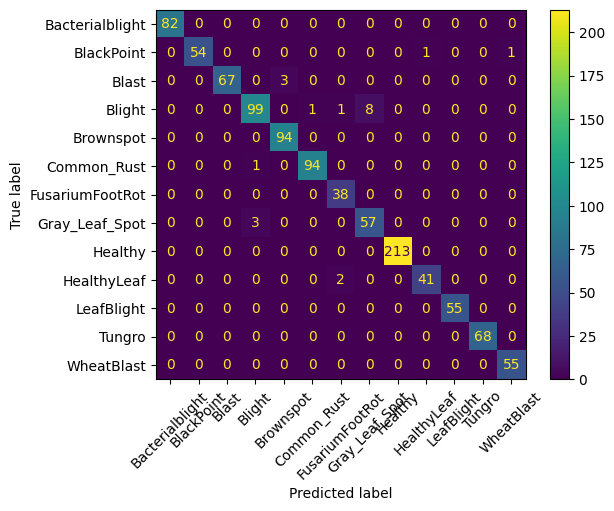

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = train_ds.features['label'].names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

**Recall**

In [ ]:
from sklearn.metrics import recall_score

# Calculate the recall scores
# 'None' calculates recall for each class separately
recall = recall_score(y_true, y_pred, average=None)

# Print the recall for each class
for label, score in zip(labels, recall):
    print(f'Recall for {label}: {score:.2f}')

Recall for Bacterialblight: 1.00
Recall for BlackPoint: 0.96
Recall for Blast: 0.96
Recall for Blight: 0.91
Recall for Brownspot: 1.00
Recall for Common_Rust: 0.99
Recall for FusariumFootRot: 1.00
Recall for Gray_Leaf_Spot: 0.95
Recall for Healthy: 1.00
Recall for HealthyLeaf: 0.95
Recall for LeafBlight: 1.00
Recall for Tungro: 1.00
Recall for WheatBlast: 1.00


# **Pushing Model to HF Hub**

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
model.push_to_hub("Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS")
extractor.push_to_hub("Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rtgg2tx/model.safetensors:   0%|          |  553kB /  343MB            

CommitInfo(commit_url='https://huggingface.co/Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS/commit/c9d34122f06c612c384c60450a657df022c47ea3', commit_message='Upload processor', commit_description='', oid='c9d34122f06c612c384c60450a657df022c47ea3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS', endpoint='https://huggingface.co', repo_type='model', repo_id='Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS'), pr_revision=None, pr_num=None)

In [ ]:
MODEL_NAME="Hhsjsnns/Rice-Wheat-Corn-DiseaseCLS"
extractor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]